In [ ]:
# Step 1 : Install Required Libraries
# pip install tensorflow keras numpy matplotlib scikit-learn

In [ ]:
# Step 2: Import Libraries
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.datasets import mnist
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

In [ ]:
#Step 3: Load and Preprocess the MNIST Dataset
# Load the MNIST dataset
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Normalize and reshape the images
train_images = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255
test_images = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255

# One-hot encode the labels
train_labels = keras.utils.to_categorical(train_labels, 10)
test_labels = keras.utils.to_categorical(test_labels, 10)

In [ ]:
# Step 4: Set Up Data Augmentation
datagen = ImageDataGenerator(
 rotation_range=40,
 width_shift_range=0.2,
 height_shift_range=0.2,
 shear_range=0.2,
 zoom_range=0.2,
 horizontal_flip=True,
 fill_mode='nearest'
)

# Fit the data generator to the training images
datagen.fit(train_images)


In [ ]:
# Step 5: Build the Neural Network Model
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

# Display the model's architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Step 6: Compile and Train the Model
# Compile the model
model.compile(optimizer='adam',
 loss='categorical_crossentropy',
 metrics=['accuracy'])

# Train the model with data augmentation
history = model.fit(datagen.flow(train_images, train_labels, batch_size=32),
 steps_per_epoch=int(len(train_images) / 32),
 epochs=3,
 validation_data=(test_images, test_labels))

Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 43ms/step - accuracy: 0.4962 - loss: 1.4307 - val_accuracy: 0.9055 - val_loss: 0.3106
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 78s 42ms/step - accuracy: 0.8348 - loss: 0.5127 - val_accuracy: 0.9460 - val_loss: 0.1645
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 41ms/step - accuracy: 0.8793 - loss: 0.3810 - val_accuracy: 0.9535 - val_loss: 0.1446


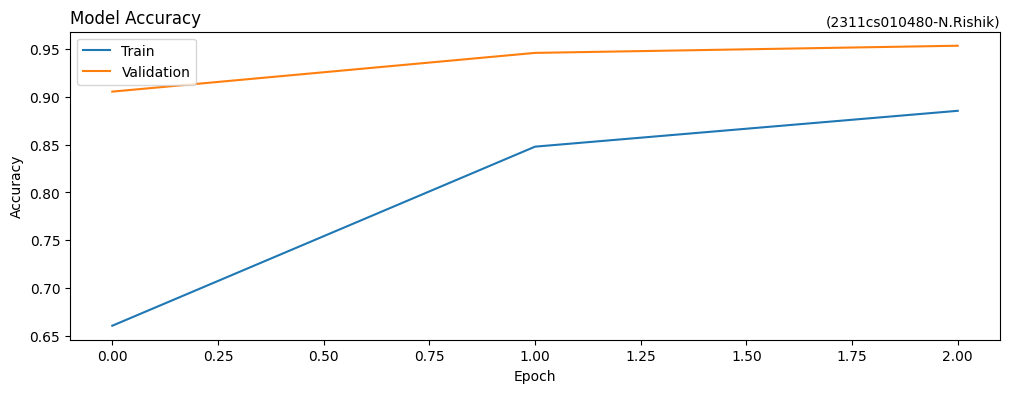

In [ ]:
#Step 7: Plot Training History
# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
# plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy',loc='left')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.text(1.0,1.02,'(2311cs010480-N.Rishik)',transform=plt.gca().transAxes,ha='right')
plt.legend(['Train', 'Validation'], loc='upper left')



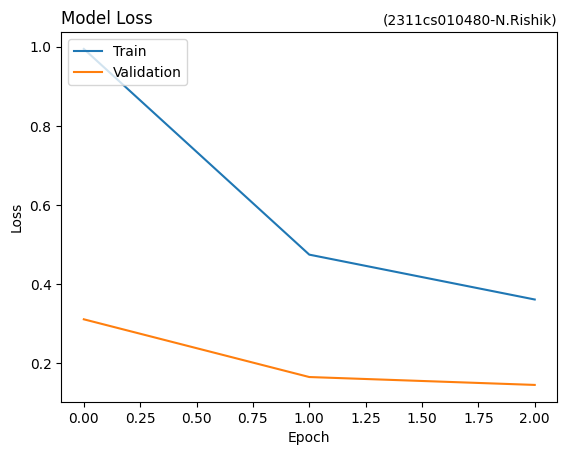

In [ ]:
# Plot training & validation loss values
# plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss',loc='left')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.text(1.0,1.02,'(2311cs010480-N.Rishik)',transform=plt.gca().transAxes,ha='right')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
#Step 8: Make Predictions and Generate a Classification Report
# Make predictions
predictions = model.predict(test_images)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(test_labels, axis=1)

# Generate a classification report
print(classification_report(true_classes, predicted_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.92      0.90      0.91      1032
           3       0.94      0.99      0.96      1010
           4       0.99      0.96      0.97       982
           5       0.87      0.95      0.91       892
           6       0.95      0.97      0.96       958
           7       0.96      0.91      0.93      1028
           8       0.95      0.96      0.96       974
           9       0.97      0.92      0.94      1009

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



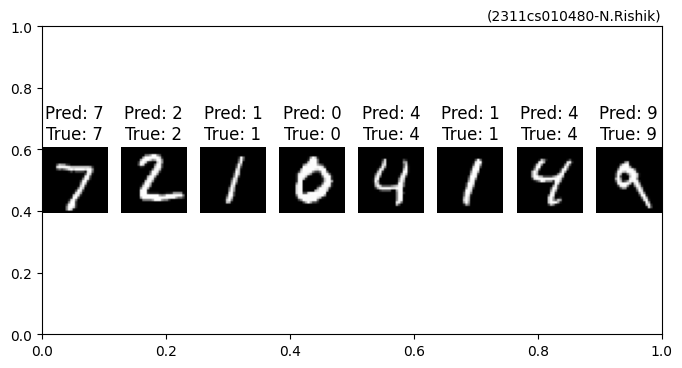

In [ ]:
# Step 9: Visualize Some Predictions
# Display a few test images with their predicted and true labels
num_images = 8
plt.figure(figsize=(8, 4))
plt.text(1.0,1.02,'(2311cs010480-N.Rishik)',transform=plt.gca().transAxes,ha='right')
for i in range(num_images):
  plt.subplot(1, num_images, i + 1)
  plt.imshow(test_images[i].reshape(28, 28), cmap='gray')
  plt.title(f"Pred: {predicted_classes[i]}\nTrue: {true_classes[i]}")
  plt.axis('off')
plt.show()

In [ ]:
#Step 10: Evaluate the Model on Test Data
# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f'Test accuracy: {test_acc:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9439 - loss: 0.1660
Test accuracy: 0.9535
